# 09 — Small Multiples
**When to use:** You want to compare the same chart across many segments (channels, months, device types) without cluttering a single chart.

The key insight: **same scale, same layout, different data.** The reader's eye can instantly compare panels.

In [1]:
import os
os.chdir('/Volumes/SSD_Gabo/proyectos/growth-analytics')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import calendar

df = pd.read_csv('data/raw/funnel_data.csv', parse_dates=['date'])
df['month'] = df['date'].dt.month
df['week']  = df['date'].dt.isocalendar().week.astype(int)

PALETTE = ['#4361ee', '#f72585', '#06d6a0', '#ff9f1c', '#7209b7']
CHANNELS = sorted(df['channel'].unique())

print(CHANNELS)

['direct', 'email', 'organic', 'paid', 'social']


## 1. CVR trend — one panel per channel

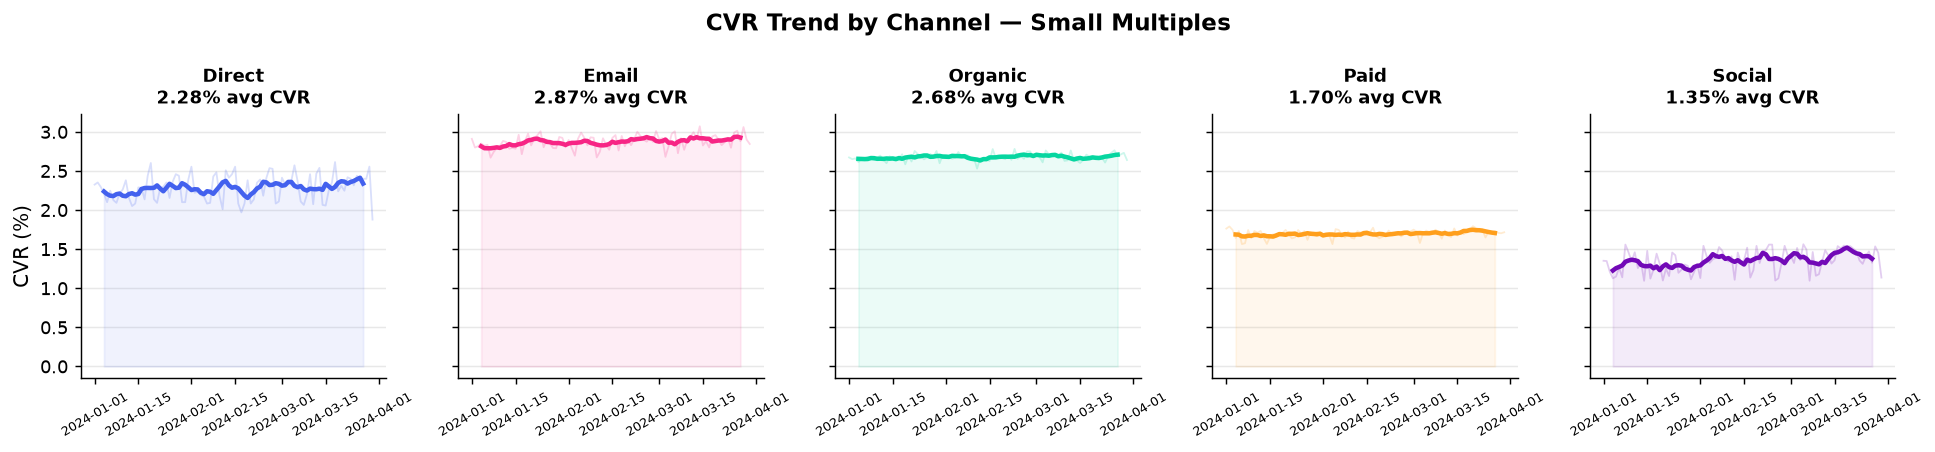

In [2]:
fig, axes = plt.subplots(1, len(CHANNELS), figsize=(15, 3.5), dpi=130,
                          sharey=True)   # same y-scale = fair comparison

for ax, ch, color in zip(axes, CHANNELS, PALETTE):
    ch_df = df[df['channel'] == ch].groupby('date').apply(
        lambda g: g['activacion_tarjeta'].sum() / g['visita_landing'].sum() * 100
    ).reset_index(name='cvr')

    # 7-day rolling mean to smooth noise
    ch_df['cvr_roll'] = ch_df['cvr'].rolling(7, center=True).mean()

    ax.plot(ch_df['date'], ch_df['cvr'], color=color, alpha=0.2, linewidth=1)
    ax.plot(ch_df['date'], ch_df['cvr_roll'], color=color, linewidth=2.5)
    ax.fill_between(ch_df['date'], ch_df['cvr_roll'], alpha=0.08, color=color)

    # Panel title with mean CVR
    mean_cvr = ch_df['cvr'].mean()
    ax.set_title(f'{ch.capitalize()}\n{mean_cvr:.2f}% avg CVR',
                 fontsize=10, fontweight='bold')

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='x', rotation=30, labelsize=7)
    ax.grid(axis='y', color='#e8e8e8', linewidth=0.8)
    ax.set_axisbelow(True)

axes[0].set_ylabel('CVR (%)', fontsize=11)
fig.suptitle('CVR Trend by Channel — Small Multiples', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('data/09_small_multiples_cvr.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Funnel shape per channel — each panel shows the full funnel

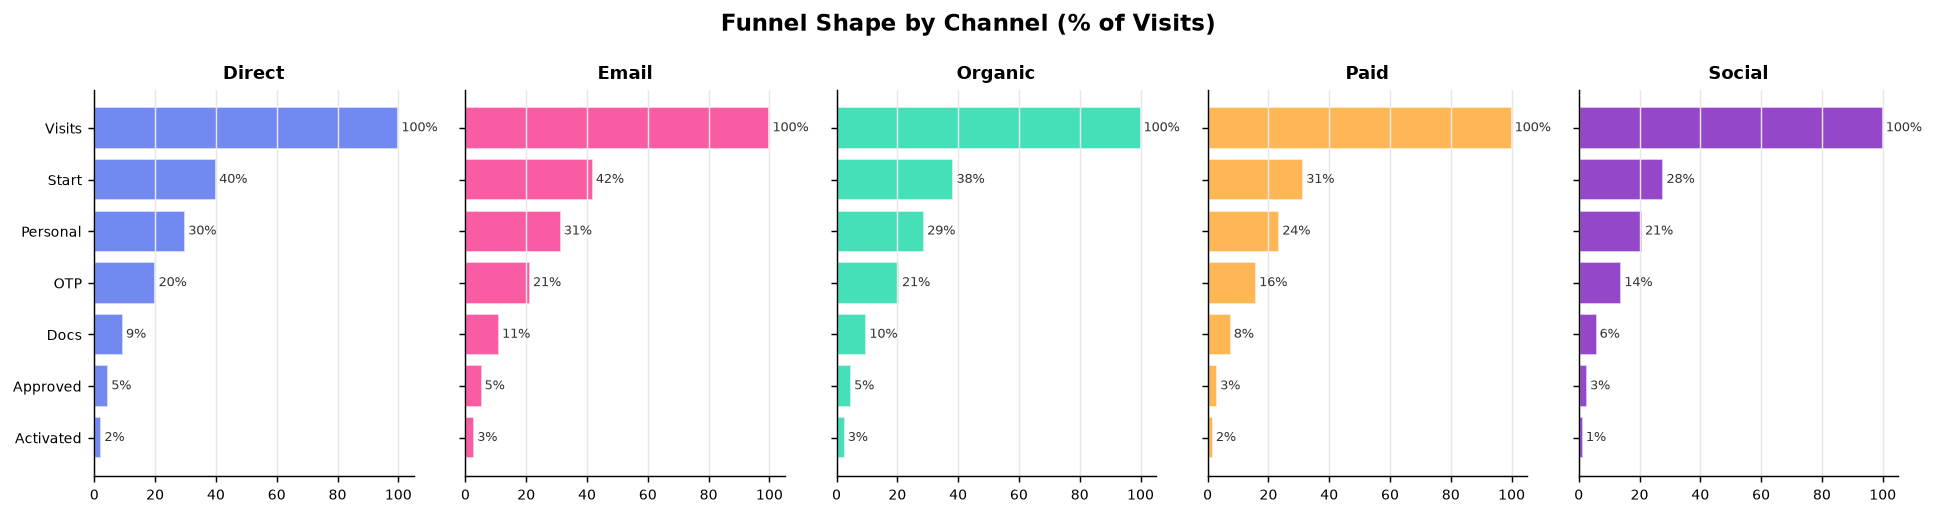

In [3]:
STEPS = ['visita_landing','inicio_solicitud','datos_personales','otp',
         'carga_documentos','aprobacion','activacion_tarjeta']
LABELS = ['Visits','Start','Personal','OTP','Docs','Approved','Activated']

fig, axes = plt.subplots(1, len(CHANNELS), figsize=(15, 4), dpi=130,
                          sharey=True)

for ax, ch, color in zip(axes, CHANNELS, PALETTE):
    totals = df[df['channel'] == ch][STEPS].sum()

    # Normalize each step relative to visits (100%)
    normalized = totals / totals['visita_landing'] * 100

    ax.barh(LABELS, normalized.values, color=color, alpha=0.75, edgecolor='white')
    ax.set_title(ch.capitalize(), fontsize=10, fontweight='bold')
    ax.set_xlim(0, 105)
    ax.invert_yaxis()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='x', color='#e8e8e8', linewidth=0.8)
    ax.tick_params(labelsize=8)

    # Add % labels
    for i, val in enumerate(normalized.values):
        ax.text(val + 1, i, f'{val:.0f}%', va='center', fontsize=7, color='#333')

fig.suptitle('Funnel Shape by Channel (% of Visits)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('data/09_small_multiples_funnel.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Monthly breakdown — same chart repeated by month

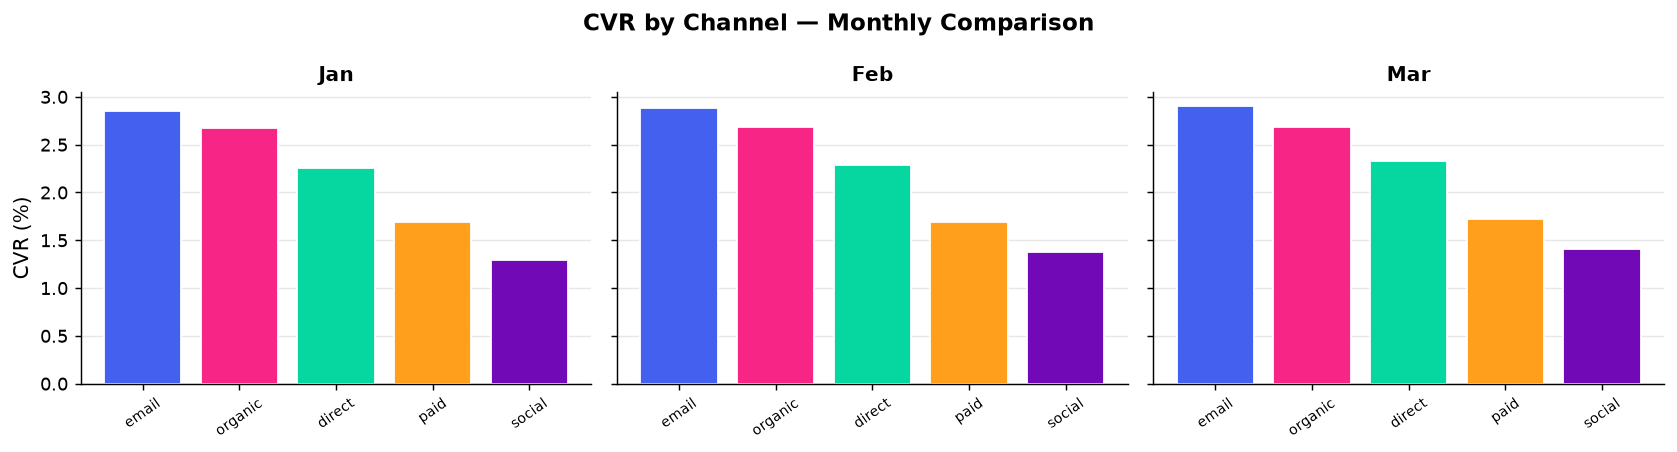

In [4]:
months = sorted(df['month'].unique())
month_names = [calendar.month_abbr[m] for m in months]

fig, axes = plt.subplots(1, len(months), figsize=(13, 3.5), dpi=130,
                          sharey=True, sharex=False)

for ax, month, name in zip(axes, months, month_names):
    m_df = df[df['month'] == month].groupby('channel').agg(
        visits=('visita_landing', 'sum'),
        activations=('activacion_tarjeta', 'sum')
    ).reset_index()
    m_df['cvr'] = m_df['activations'] / m_df['visits'] * 100
    m_df = m_df.sort_values('cvr', ascending=False)

    bars = ax.bar(m_df['channel'], m_df['cvr'],
                  color=PALETTE[:len(m_df)], edgecolor='white')
    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.tick_params(axis='x', rotation=35, labelsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', color='#e8e8e8', linewidth=0.8)
    ax.set_axisbelow(True)

axes[0].set_ylabel('CVR (%)', fontsize=11)
fig.suptitle('CVR by Channel — Monthly Comparison', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

## Summary
| | |
|---|---|
| **Pattern** | `plt.subplots(1, n)` + loop over segments |
| **Same scale** | `sharey=True` or `sharex=True` — critical for fair comparison |
| **Consistent style** | Apply same styling inside the loop |
| **When to use** | Comparing the same metric across channels, months, cohorts |
| **Avoid** | More than ~8 panels — use a heatmap instead |

**Next:** `10_waterfall.ipynb`